In [4]:
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
ds_gfs = xr.open_dataset('GFS_UPDATED_V1.nc')

In [5]:
ds_sla = xr.open_dataset('SLA_UPDATED.nc')


In [36]:
vars = list(ds_gfs.data_vars)

In [37]:
means = {}

for var in vars:
    means[var] = ds_gfs[var].mean(dim=["latitude", "longitude"])

In [42]:
for key,val in means.items():
    print(key)

UGRD_10maboveground
VGRD_10maboveground
DSWRF_surface
USWRF_surface
DLWRF_surface
ULWRF_surface
TMP_surface
TMP_2maboveground
SPFH_2maboveground
PRATE_surface


In [45]:
means['UGRD_10maboveground'].values

array([-0.78924227, -1.38653   , -1.6228508 , ...,  1.9112029 ,
        2.2731822 ,  2.3710299 ], shape=(3930,), dtype=float32)

In [47]:
sla_mean = ds_sla.sla.mean(dim=["latitude","longitude"])

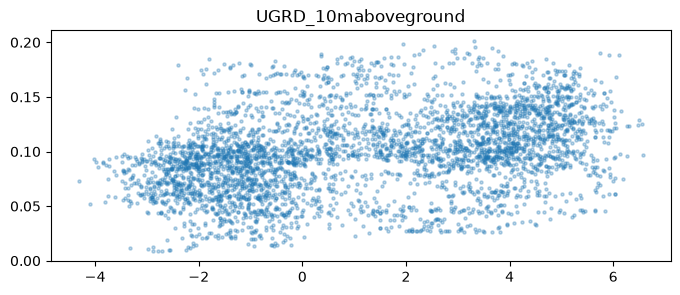

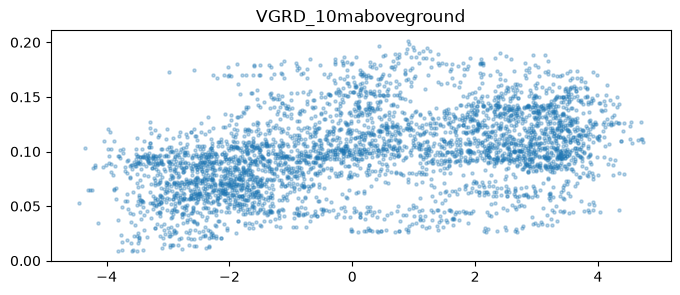

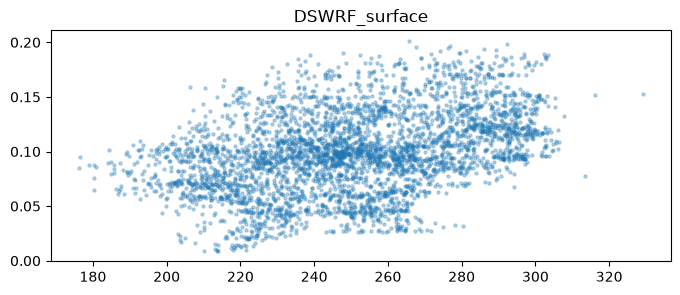

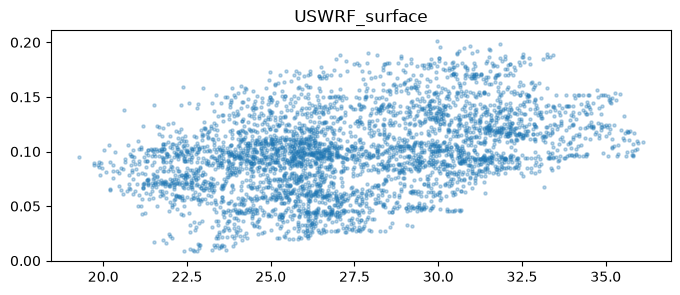

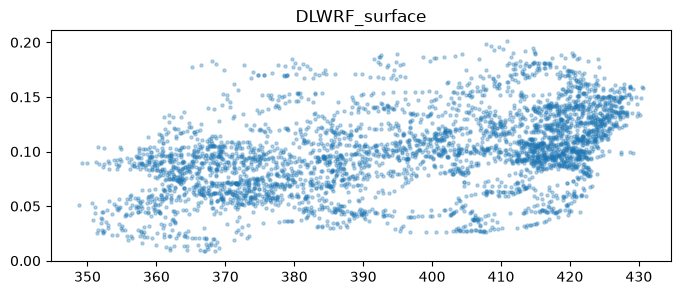

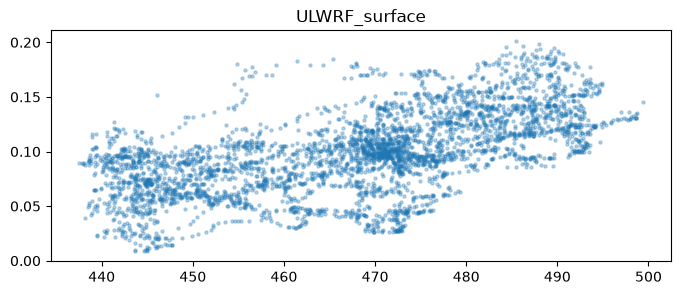

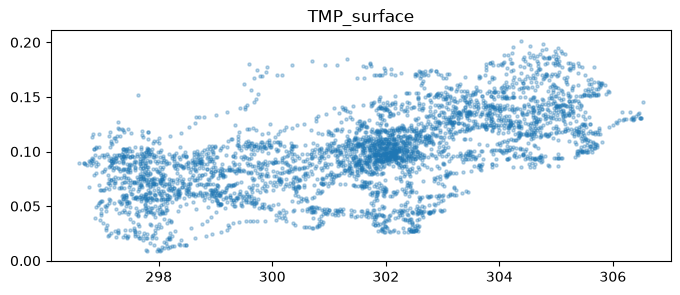

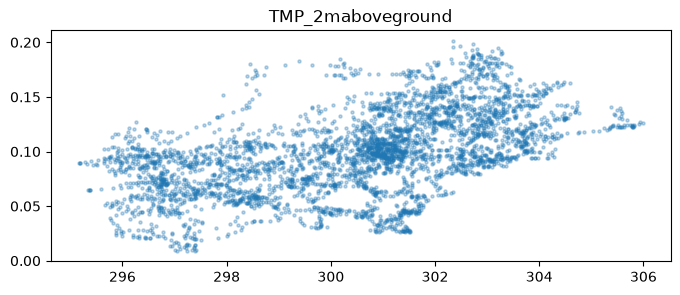

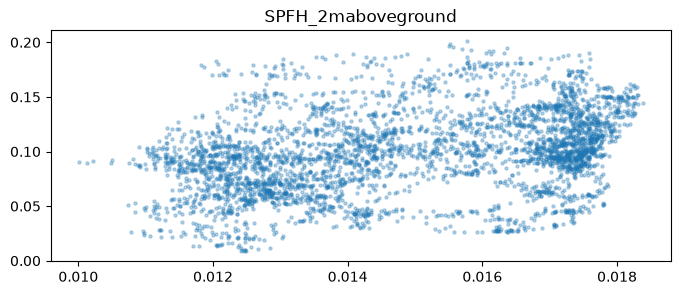

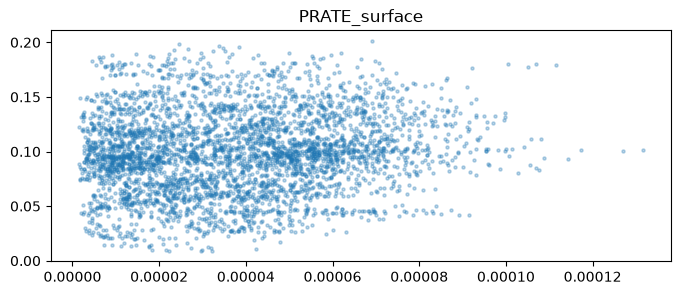

In [62]:
for var in vars:
    plt.figure(figsize=(8,3))
    plt.scatter(means[var].values, sla_mean.values, s=5, alpha=0.3)
    plt.title(var)
    plt.show()

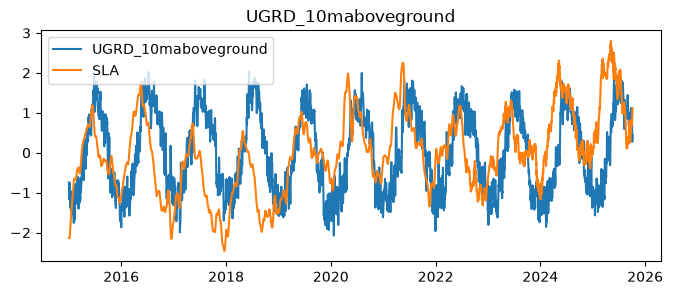

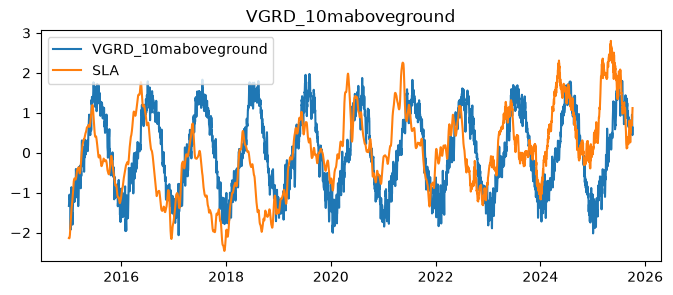

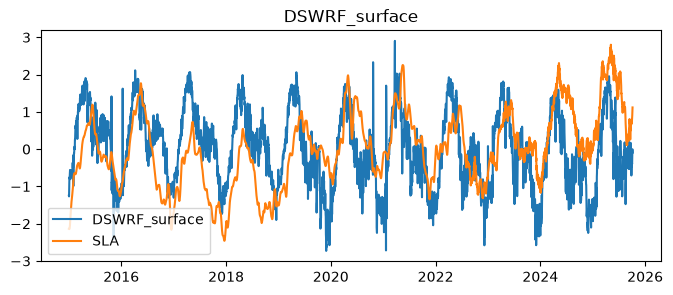

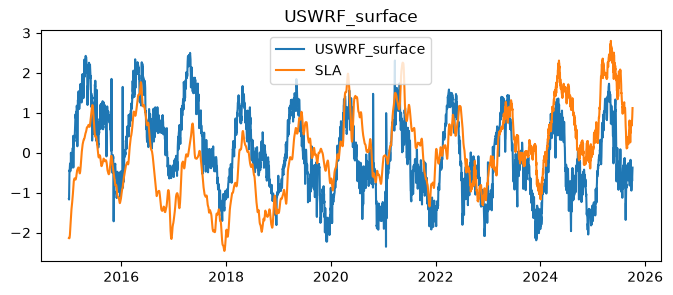

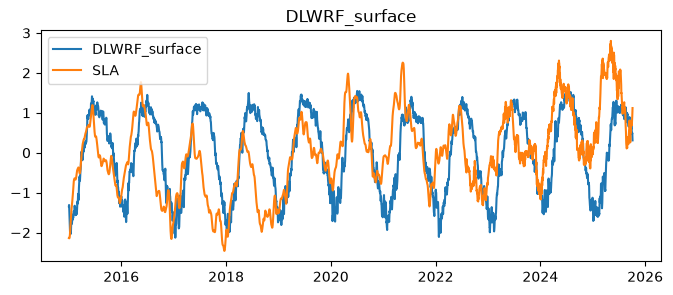

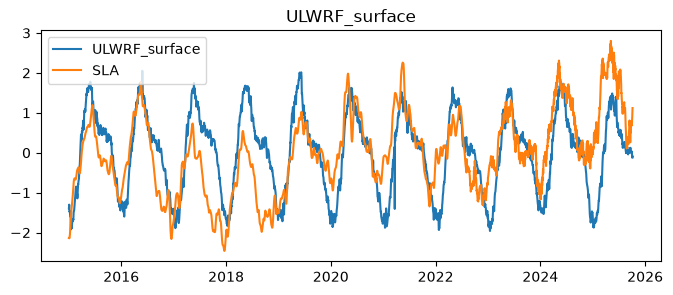

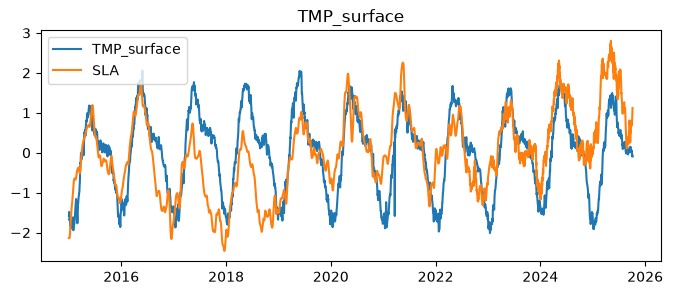

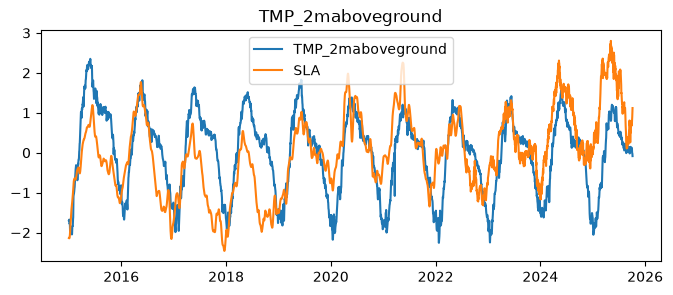

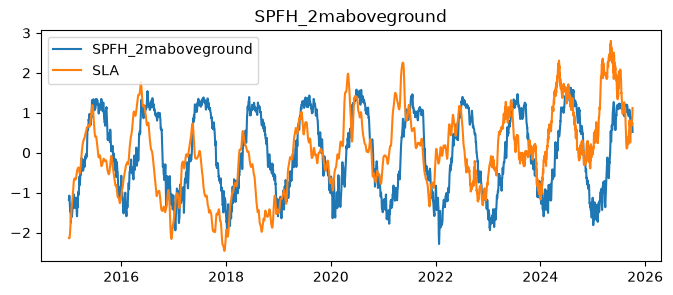

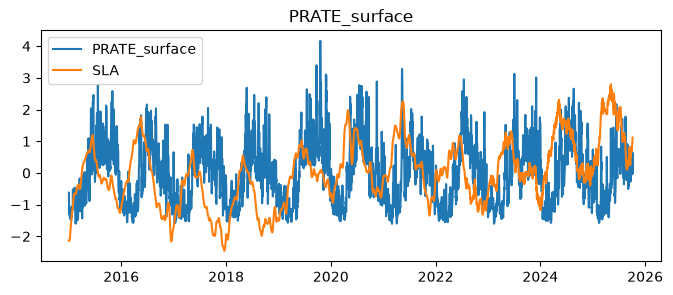

In [67]:
for var in vars:
    plt.figure(figsize=(8,3))
    plt.plot(ds_gfs.time, (means[var] - means[var].mean()) / means[var].std(),label=var)
    plt.plot(ds_sla.time, (sla_mean - sla_mean.mean()) / sla_mean.std(),label="SLA")
    plt.title(var)
    plt.legend()
    plt.show()


In [59]:
sla_mean.values

array([0.02072163, 0.02059528, 0.02052336, ..., 0.1319405 , 0.13588369,
       0.13980198], shape=(3930,), dtype=float32)

In [ ]:
ds_sla.sla.values

array([[[-0.0456    , -0.0489    , -0.0511    , ...,  0.1642    ,
          0.1654    ,  0.163     ],
        [-0.0481    , -0.051     , -0.0533    , ...,  0.1672    ,
          0.1662    ,  0.1652    ],
        [-0.0471    , -0.0525    , -0.0559    , ...,  0.1657    ,
          0.1659    ,  0.1661    ],
        ...,
        [ 0.0767    ,  0.0843    ,  0.0947    , ...,         nan,
                 nan,         nan],
        [ 0.0789    ,  0.0965    ,  0.0838    , ...,         nan,
                 nan,         nan],
        [ 0.0973    ,  0.1024    ,  0.0841    , ...,         nan,
                 nan,         nan]],

       [[-0.0467    , -0.0506    , -0.0533    , ...,  0.1515    ,
          0.1531    ,  0.1524    ],
        [-0.0482    , -0.0532    , -0.0571    , ...,  0.1543    ,
          0.1538    ,  0.1546    ],
        [-0.0515    , -0.0558    , -0.0596    , ...,  0.1537    ,
          0.1545    ,  0.1543    ],
        ...,
        [ 0.0918    ,  0.0882    ,  0.0943    , ...,  

In [26]:
ds_sla["sla_cm"] = ds_sla["sla"]*100

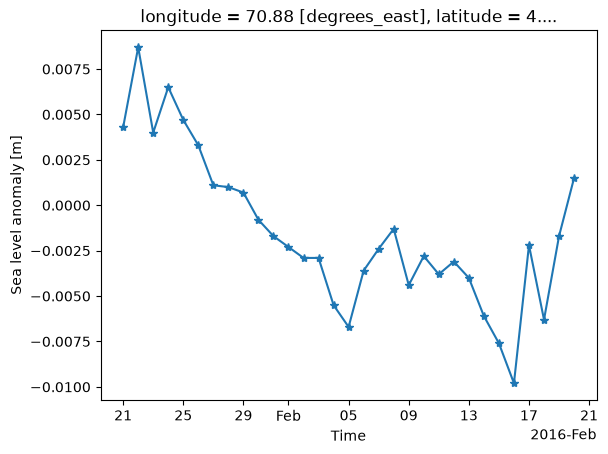

In [ ]:
ds_sla.sla.isel(latitude=18,longitude=83).sel(time=slice("2016-01-20","2016-02-20")).diff(dim="time").plot(
    marker="*"
)

/home/charan/sla_pred/venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


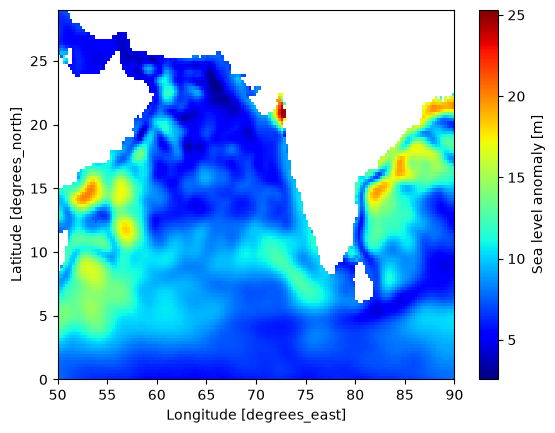

In [30]:
ds_sla.sla_cm.sel(time=slice("2016-01-20","2017-01-20")).std(dim="time").plot(
    cmap="jet"
)